<h1 align="center">
  <span style="background: linear-gradient(90deg, #6383ecff, #2e28ccff); 
               -webkit-background-clip: text; 
               -webkit-text-fill-color: transparent;">
    AIRFOL SELF-NOISE DATASET
  </span>
</h1>


---

<h1 style="color:#2e28ccff; background-color:'white'">Preparación de datos</h1>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter  
from torch.utils.data import random_split
from torch.utils.data import Dataset
from random import sample


In [2]:
class AirfolSelfNoiseDataset(Dataset):
    def __init__(self, csv_file, root_dir='', transform=None):
        # 1. Cargar datos
        airfolDataset = pd.read_csv(csv_file, sep=r'\s+', header=None, 
                                    names=["frequency", "angle_of_attack", "chord_length", 
                                        "free_stream_velocity", "suction_side_displacement_thickness", 
                                        "sound_pressure_level"])

        #DIVIDIR EL DATASET
        X = airfolDataset.iloc[:, 0:5].values
        y = airfolDataset.iloc[:, 5].values

        #Convertir a tensores 
        y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)
        X_tensor = torch.tensor(X, dtype=torch.float32)

        #ESCALAR LOS DATOS X
        scaler = StandardScaler()
        X_scaled = torch.tensor(scaler.fit_transform(X_tensor), dtype=torch.float32)
        
        # SE UNE TODO  
        self.data = torch.cat((X_scaled, y_tensor), 1)
        
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        # Las primeras 5 columnas son X
        preds = self.data[idx, 0:5]
        # La última columna (índice 5) es Y
        spcs = self.data[idx, 5:]
        
        sample = (preds, spcs)
        if self.transform:
            sample = self.transform(sample)
        return sample

In [4]:
dataset = AirfolSelfNoiseDataset(csv_file='../../docs/airfoil/airfoil_self_noise.dat')
print(f"Total samples in dataset: {len(dataset)}")
display(dataset[0])  

Total samples in dataset: 1503


(tensor([-0.6620, -1.1464,  1.7993,  1.3129, -0.6448]), tensor([126.2010]))

In [ ]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.layer1 = nn.Linear(input_dim, 50)
        self.layer2 = nn.Linear(50, 50)
        self.layer3 = nn.Linear(50, 1)
        
    def forward(self, x):
        # relu es una función de activación que introduce no linealidad en el modelo, lo que permite aprender relaciones más complejas entre las características de entrada y la salida.
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        return self.layer3(x)

In [15]:
model     = Model(13)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()
display(model)

Model(
  (layer1): Linear(in_features=13, out_features=50, bias=True)
  (layer2): Linear(in_features=50, out_features=50, bias=True)
  (layer3): Linear(in_features=50, out_features=1, bias=True)
)

Separación 80/20

In [10]:
tamTRAIN = int(0.8 * len(dataset))
tamTEST = len(dataset) - tamTRAIN
train_dataset, test_dataset = random_split(dataset, [tamTRAIN, tamTEST])

DataLoaders, los datos se le envian poco a poco por el tema de la Ram , se necesita estudiarlos poco a poco , y eso es lo que hace nuestros DataLoaders


In [11]:
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
validation_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2)

In [17]:
model = Model(5)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

entradaProba, dest = next(iter(train_loader))
print("Entrada:")
display(entradaProba)
print("Desexada:")
display(dest)
saida = model(entradaProba)  # esta é a proba de verdade
print("Saída:")
display(saida)
loss = loss_fn(saida, dest)
display(loss)

Entrada:


tensor([[-0.7160, -0.6393,  1.7993,  0.2980, -0.5032],
        [-0.6620,  0.7467, -0.9170, -0.7233,  0.2973]])

Desexada:


tensor([[129.5690],
        [133.7900]])

Saída:


tensor([[0.0322],
        [0.0914]], grad_fn=<AddmmBackward0>)

tensor(17327.5566, grad_fn=<MseLossBackward0>)

In [18]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.
    # usamos enumerate para saber en que batch imos
    for i, data in enumerate(train_loader):
        # Every data instance is an input + label pair
        inputs, labels = data
        # Zero your gradients for every batch!
        optimizer.zero_grad()
        # Make predictions for this batch
        outputs = model(inputs)
        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()
        # Adjust learning weights
        optimizer.step()
        # Gather data and report
        running_loss += loss.item()
        if i % 10 == 9:
            last_loss = running_loss / 10 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            running_loss = 0.
    return last_loss

In [20]:
EPOCHS = 100
loss_list     = torch.zeros((EPOCHS,))
accuracy_list = torch.zeros((EPOCHS,))

# Crear o SummaryWriter para TensorBoard 
writer = SummaryWriter()

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch + 1))

    # Poñemos o modelo en modo entrenamento
    model.train(True)
    avg_loss = train_one_epoch(epoch, writer)
    loss_list[epoch] = avg_loss
    # Non se precisan os gradientes para o test
    model.train(False)

EPOCH 1:
  batch 10 loss: 15358.585546875
  batch 20 loss: 15754.04794921875
  batch 30 loss: 15718.378515625
  batch 40 loss: 14934.82529296875
  batch 50 loss: 15202.46435546875
  batch 60 loss: 14761.973828125
  batch 70 loss: 15072.80859375
  batch 80 loss: 14766.20458984375
  batch 90 loss: 14202.8001953125
  batch 100 loss: 14137.63642578125
  batch 110 loss: 13268.68076171875
  batch 120 loss: 12806.375
  batch 130 loss: 12147.49267578125
  batch 140 loss: 11992.184375
  batch 150 loss: 10517.25283203125
  batch 160 loss: 9433.1837890625
  batch 170 loss: 8485.3744140625
  batch 180 loss: 7129.702099609375
  batch 190 loss: 5720.14169921875
  batch 200 loss: 5469.184790039062
  batch 210 loss: 3867.856555175781
  batch 220 loss: 2900.6749633789063
  batch 230 loss: 2430.8485717773438
  batch 240 loss: 1710.2053619384765
  batch 250 loss: 2344.504934692383
  batch 260 loss: 1292.8986022949218
  batch 270 loss: 679.8522087097168
  batch 280 loss: 701.3925132751465
  batch 290 loss

In [ ]:
plt.style.use('ggplot')
fig, (ax2) = plt.subplots(1, figsize=(12, 6), sharex=True)
ax2.plot(loss_list)
ax2.set_ylabel("validation loss")
ax2.set_xlabel("epochs")

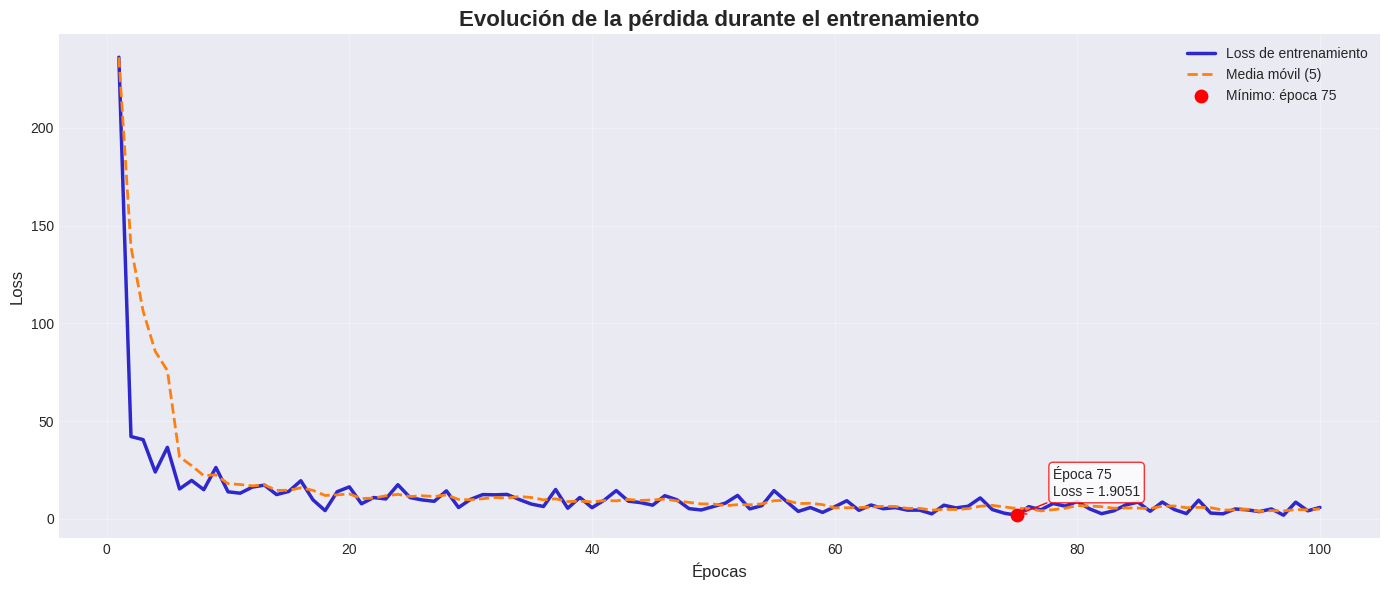

In [23]:
plt.style.use('seaborn-v0_8-darkgrid')

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(range(1, EPOCHS + 1), loss_list.numpy(), color='#2e28cc', linewidth=2.5, label='Loss de entrenamiento')

if EPOCHS >= 5:
    loss_series = pd.Series(loss_list.numpy())
    smooth_loss = loss_series.rolling(window=5, min_periods=1).mean()
    ax.plot(range(1, EPOCHS + 1), smooth_loss, color='#ff7f0e', linewidth=2, linestyle='--', label='Media móvil (5)')

best_epoch = torch.argmin(loss_list).item() + 1
best_loss = torch.min(loss_list).item()

ax.scatter(best_epoch, best_loss, color='red', s=80, zorder=5, label=f'Mínimo: época {best_epoch}')
ax.annotate(
    f'Época {best_epoch}\nLoss = {best_loss:.4f}',
    xy=(best_epoch, best_loss),
    xytext=(best_epoch + 3, best_loss + 10),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='red', alpha=0.8)
)

ax.set_title('Evolución de la pérdida durante el entrenamiento', fontsize=16, fontweight='bold')
ax.set_xlabel('Épocas', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

------

<div style="font-family: 'Segoe UI', Arial, sans-serif; background: linear-gradient(135deg,#0f2027,#203a43,#2c5364); padding:40px; border-radius:15px; color:white;">

<h1 style="text-align:center; color:#7fd3ff; text-shadow:0 0 10px rgba(0,150,255,0.8);">
Red Neuronal
</h1>

<!-- PREPARACION DE DATOS -->
<div style="background:linear-gradient(145deg,#1b3c5a,#0f2538); padding:25px; margin-top:25px; border-radius:12px; box-shadow:0 10px 25px rgba(0,0,0,0.5);">

<h2 style="color:#6ec6ff; border-bottom:2px solid #3fa9f5; padding-bottom:8px;">
1. Preparación de Datos
</h2>

<ol style="line-height:1.8;">
<li><b>Preparar los datos:</b> cargar el dataset y las librerías necesarias.</li>
<li><b>Separar X e Y:</b> dividir los datos de entrada (features) y la variable objetivo.</li>
<li><b>Escalar:</b> normalizar o estandarizar los datos para mejorar el entrenamiento.</li>
<li><b>Convertir:</b> transformar los datos al formato necesario (por ejemplo, tensores en PyTorch).</li>
</ol>

</div>

<!-- RED NEURONAL -->
<div style="background:linear-gradient(145deg,#1b3c5a,#0f2538); padding:25px; margin-top:25px; border-radius:12px; box-shadow:0 10px 25px rgba(0,0,0,0.5);">

<h2 style="color:#6ec6ff; border-bottom:2px solid #3fa9f5; padding-bottom:8px;">
2. Red Neuronal
</h2>

<ol style="line-height:1.8;">
<li><b>Capa de entrada:</b> una neurona por cada columna de los datos de entrada.</li>
<li><b>Capa oculta:</b> capas intermedias con el número de neuronas que quieras (por ejemplo 64, 32, etc.).</li>
<li><b>Capa de salida:</b> normalmente una neurona cuando se quiere predecir un único valor.</li>
</ol>

</div>

<!-- ENTRENAMIENTO -->
<div style="background:linear-gradient(145deg,#1b3c5a,#0f2538); padding:25px; margin-top:25px; border-radius:12px; box-shadow:0 10px 25px rgba(0,0,0,0.5);">

<h2 style="color:#6ec6ff; border-bottom:2px solid #3fa9f5; padding-bottom:8px;">
3. Configuración del Entrenamiento
</h2>

<ol style="line-height:1.8;">
<li>
<b>Función de pérdida:</b> si es un problema de regresión se suele usar 
<span style="color:#7fd3ff;">nn.MSELoss()</span>, que calcula el error cuadrático medio.
</li>

<li>
<b>Optimizador:</b> el mecanismo que ajusta los pesos de la red para reducir el error.  
<span style="color:#7fd3ff;">torch.optim.Adam</span> suele ser una de las mejores opciones.
</li>
</ol>

</div>

<!-- PROCESO DE ENTRENAMIENTO -->
<div style="background:linear-gradient(145deg,#1b3c5a,#0f2538); padding:25px; margin-top:25px; border-radius:12px; box-shadow:0 10px 25px rgba(0,0,0,0.5);">

<h2 style="color:#6ec6ff; border-bottom:2px solid #3fa9f5; padding-bottom:8px;">
4. Proceso de Entrenamiento
</h2>

<ol style="line-height:1.8;">
<li>El modelo toma un lote de datos de entrada <b>X</b>.</li>

<li>Realiza una <b>predicción</b> (por ejemplo, estimar los decibelios generados).</li>

<li>Calcula el <b>error</b> comparando la predicción con el valor real usando la función de pérdida.</li>

<li>La red <b>aprende</b>: el optimizador ajusta los pesos y conexiones matemáticas para reducir el error en la siguiente iteración.</li>
</ol>

</div>

</div>

![Red neuronal](../../docs/rednueronal.png)